## 1. Installation

In [1]:
!pip install transformers>=4.36.0
!pip install sacrebleu>=2.4.0
!pip install bert-score>=0.3.13
!pip install pandas>=2.0.0
!pip install numpy>=1.24.0
!pip install torch>=2.0.0
!pip install tqdm
!pip install sentencepiece
!pip install accelerate

## 2. Imports and Setup

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    MarianTokenizer,
    MarianMTModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm.auto import tqdm
import sacrebleu
from bert_score import score as bert_score
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/DATA/suraj/m1/ss1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA L4
GPU Memory: 23.7 GB


## 3. Data Loading

In [3]:
DATA_PATH = './data'

def load_parallel_data(data_dir):
    """Load Sanskrit-English parallel data from CSV files"""

    train_sa = pd.read_csv(os.path.join(data_dir, 'train_sa_10000.csv'))
    train_en = pd.read_csv(os.path.join(data_dir, 'train_en_10000.csv'))
    dev_sa   = pd.read_csv(os.path.join(data_dir, 'dev_sa_1000.csv'))
    dev_en   = pd.read_csv(os.path.join(data_dir, 'dev_en_1000.csv'))
    test_sa  = pd.read_csv(os.path.join(data_dir, 'test_sa_1000.csv'))
    test_en  = pd.read_csv(os.path.join(data_dir, 'test_en_1000.csv'))

    train_data = list(zip(train_sa['Sentence_sa'].tolist(), train_en['Sentence_en'].tolist()))
    dev_data   = list(zip(dev_sa['Sentence_sa'].tolist(),   dev_en['Sentence_en'].tolist()))
    test_data  = list(zip(test_sa['Sentence_sa'].tolist(),  test_en['Sentence_en'].tolist()))

    print(f"Training pairs:    {len(train_data):,}")
    print(f"Development pairs: {len(dev_data):,}")
    print(f"Test pairs:        {len(test_data):,}")

    return (
        train_data, dev_data, test_data,
        test_sa['Source_id'].tolist(),
        dev_sa['Source_id'].tolist() if 'Source_id' in dev_sa.columns else None
    )

# Load data
train_data, dev_data, test_data, test_ids, dev_ids = load_parallel_data(DATA_PATH)

# Extract sentences for convenience
train_sa = [pair[0] for pair in train_data]
train_en = [pair[1] for pair in train_data]
dev_sa   = [pair[0] for pair in dev_data]
dev_en   = [pair[1] for pair in dev_data]
test_sa  = [pair[0] for pair in test_data]
test_en  = [pair[1] for pair in test_data]


print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)
print(f"Sanskrit: {train_sa[0][:100]}")
print(f"English:  {train_en[0][:100]}")

Training pairs:    10,000
Development pairs: 1,000
Test pairs:        1,000

SAMPLE DATA
Sanskrit: "Ctrl, S नुत्वा रक्षन्तु।"
English:  Save it with Ctrl, S.


## 4. Dataset Class

In [4]:
class TranslationDataset(Dataset):


    def __init__(self, pairs, tokenizer, max_source_length=128, max_target_length=128):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_source_length = max_source_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        source, target = self.pairs[idx]

        source_inputs = self.tokenizer(
            source,
            max_length=self.max_source_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        target_inputs = self.tokenizer(
            target,
            max_length=self.max_target_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "input_ids":      source_inputs["input_ids"].squeeze(),
            "attention_mask": source_inputs["attention_mask"].squeeze(),
            "labels":         target_inputs["input_ids"].squeeze()
        }

## 5. Fine-Tuned OPUS-MT Translator Class

In [5]:
class FineTunedOPUSMTTranslator:

    def __init__(self, model_name="Helsinki-NLP/opus-mt-sa-en"):
        print("\n" + "="*60)
        print("LOADING OPUS-MT MODEL")
        print("="*60)
        print(f"Base model: {model_name}")

        try:
            self.tokenizer = MarianTokenizer.from_pretrained(model_name)
            self.model     = MarianMTModel.from_pretrained(model_name)
            print("Loaded Sanskrit-English specific model")
        except Exception as e:
            print(f"Primary model not available: {e}")
            print("Using multilingual fallback model")
            self.tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-mul-en")
            self.model     = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-mul-en")

        self.device = device
        self.model  = self.model.to(self.device)

        print(f"\n Model loaded on {self.device}")
        print(f"  Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        self.is_fine_tuned    = False
        self.training_history = {'train_loss': [], 'eval_bleu': []}
        self.experiment_results = {}


    def fine_tune(self, train_data, dev_data, epochs=3, batch_size=8,
                  learning_rate=2e-5, warmup_steps=500, weight_decay=0.01,
                  gradient_accumulation_steps=2, max_grad_norm=1.0):


        print("\n" + "="*60)
        print("FINE-TUNING MODEL")
        print("="*60)
        print(f"Training data size:   {len(train_data)}")
        print(f"Validation data size: {len(dev_data)}")
        print(f"Epochs:               {epochs}")
        print(f"Batch size:           {batch_size} ")
        print(f"Learning rate:        {learning_rate}")

        train_dataset = TranslationDataset(train_data, self.tokenizer)
        dev_dataset   = TranslationDataset(dev_data,   self.tokenizer)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
        dev_loader   = DataLoader(dev_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)

        optimizer   = AdamW(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        total_steps = len(train_loader) * epochs
        scheduler   = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
        )

        best_bleu = 0.0
        step      = 0

        print("\nStarting training...")

        for epoch in range(epochs):
            print(f"\n{'='*50}")
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"{'='*50}")

            self.model.train()
            total_loss  = 0
            epoch_steps = 0

            progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
            for batch in progress_bar:
                input_ids      = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels         = batch["labels"].to(self.device)

                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss / gradient_accumulation_steps
                loss.backward()

                total_loss  += loss.item() * gradient_accumulation_steps
                epoch_steps += 1
                step        += 1

                if step % gradient_accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_grad_norm)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

                progress_bar.set_postfix({
                    'loss': loss.item() * gradient_accumulation_steps,
                    'lr':   scheduler.get_last_lr()[0]
                })

            avg_train_loss = total_loss / epoch_steps
            self.training_history['train_loss'].append(avg_train_loss)
            print(f"\nAverage training loss: {avg_train_loss:.4f}")

            eval_bleu = self.evaluate(dev_data, verbose=False)
            self.training_history['eval_bleu'].append(eval_bleu)
            print(f"Validation BLEU: {eval_bleu:.4f}")

            if eval_bleu > best_bleu:
                best_bleu = eval_bleu
                self.save_model('best_model')
                print(f" New best model saved! (BLEU: {best_bleu:.4f})")

        self.is_fine_tuned = True
        print(f"\n Fine-tuning completed!")
        print(f"  Best validation BLEU: {best_bleu:.4f}")

        self.load_model('best_model')
        return self.training_history

    def translate(self, texts, batch_size=16, beam_size=5, max_length=128):

        self.model.eval()
        translations = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
            batch  = texts[i:i+batch_size]
            inputs = self.tokenizer(
                batch, return_tensors="pt", padding=True,
                truncation=True, max_length=max_length
            ).to(self.device)

            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_length=max_length,
                    num_beams=beam_size,
                    early_stopping=True,
                    no_repeat_ngram_size=3,
                    length_penalty=0.6
                )

            batch_translations = self.tokenizer.batch_decode(outputs, skip_special_tokens=True)
            translations.extend(batch_translations)

        return translations


    def translate_single(self, text, beam_size=5):
        return self.translate([text], beam_size=beam_size)[0]


    def evaluate(self, data, verbose=True):
        sources    = [pair[0] for pair in data]
        references = [pair[1] for pair in data]

        translations = self.translate(sources, batch_size=16)

        bleu       = sacrebleu.corpus_bleu(translations, [references])
        bleu_score = bleu.score / 100

        if verbose:
            print(f"\nBLEU Score: {bleu_score:.4f}")
            _, _, F1 = bert_score(
                translations, references,
                lang='en', rescale_with_baseline=True, verbose=False
            )
            print(f"BERTScore F1: {F1.mean().item():.4f}")

        return bleu_score


    def save_model(self, path):
        self.model.save_pretrained(path)
        self.tokenizer.save_pretrained(path)
        print(f" Model saved to {path}")

    def load_model(self, path):
        self.model     = MarianMTModel.from_pretrained(path)
        self.tokenizer = MarianTokenizer.from_pretrained(path)
        self.model     = self.model.to(self.device)
        print(f" Model loaded from {path}")


    def get_model_info(self):
        return {
            "model_name":    self.model.config._name_or_path,
            "parameters":    sum(p.numel() for p in self.model.parameters()),
            "device":        str(self.device),
            "is_fine_tuned": self.is_fine_tuned
        }

    def plot_training_curves(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(self.training_history['train_loss'], marker='o')
        ax1.set_title('Training Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.grid(True)

        ax2.plot(self.training_history['eval_bleu'], marker='o', color='green')
        ax2.set_title('Validation BLEU Score')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('BLEU')
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=150)
        plt.show()
        print(" Training curves saved to training_curves.png")

## 6. Calculate Zero-Shot Baseline

In [6]:
print("\n" + "="*60)
print("CALCULATING ZERO-SHOT BASELINE")
print("="*60)

zero_shot_translator = FineTunedOPUSMTTranslator("Helsinki-NLP/opus-mt-sa-en")
zero_shot_bleu = zero_shot_translator.evaluate(dev_data, verbose=True)
print(f"\n Zero-shot BLEU Score: {zero_shot_bleu:.4f}")


CALCULATING ZERO-SHOT BASELINE

LOADING OPUS-MT MODEL
Base model: Helsinki-NLP/opus-mt-sa-en
Primary model not available: 401 Client Error. (Request ID: Root=1-69c55bd0-39888fda571572ab02af923d;7fe2a3be-30a4-42e0-ad19-c2b10405268d)

Repository Not Found for url: https://huggingface.co/api/models/Helsinki-NLP/opus-mt-sa-en/tree/main/additional_chat_templates?recursive=false&expand=false.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Using multilingual fallback model


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/791k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.2629

✓ Zero-shot BLEU Score: 0.0580


## 8. Initialize and Fine-Tune with Optimal Parameters

In [8]:
print("\n" + "="*60)
print("INITIALIZING TRANSLATOR WITH OPTIMAL PARAMETERS")
print("="*60)

translator = FineTunedOPUSMTTranslator("Helsinki-NLP/opus-mt-sa-en")

print("\n" + "="*60)
print("ZERO-SHOT BASELINE")
print("="*60)
test_sanskrit = "कर्मण्येवाधिकारस्ते मा फलेषु कदाचन।"
print(f"Sanskrit: {test_sanskrit}")
print(f"Translation (zero-shot): {translator.translate_single(test_sanskrit)}")


INITIALIZING TRANSLATOR WITH OPTIMAL PARAMETERS

LOADING OPUS-MT MODEL
Base model: Helsinki-NLP/opus-mt-sa-en
Primary model not available: 401 Client Error. (Request ID: Root=1-69c55d6d-0a4f4a331a7c3465093345d1;41183532-bc42-4249-803c-f017ecb0504c)

Repository Not Found for url: https://huggingface.co/api/models/Helsinki-NLP/opus-mt-sa-en/tree/main/additional_chat_templates?recursive=false&expand=false.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Using multilingual fallback model


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



✓ Model loaded on cuda
  Model parameters: 143,230,976

ZERO-SHOT BASELINE
Sanskrit: कर्मण्येवाधिकारस्ते मा फलेषु कदाचन।


Translating:   0%|          | 0/1 [00:00<?, ?it/s]

Translation (zero-shot): Maybe it's because of your work.



FINE-TUNING WITH OPTIMAL PARAMETERS

FINE-TUNING MODEL
Training data size:   10000
Validation data size: 1000
Epochs:               5
Batch size:           8 (effective: 16)
Learning rate:        3e-05

Starting training...

Epoch 1/5


Training Epoch 1:   0%|          | 0/1250 [00:00<?, ?it/s]


Average training loss: 1.3053


Translating:   0%|          | 0/63 [00:00<?, ?it/s]

Validation BLEU: 0.1128


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved to best_model
✓ New best model saved! (BLEU: 0.1947)

✓ Fine-tuning completed!
  Best validation BLEU: 0.1947


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✓ Model loaded from best_model


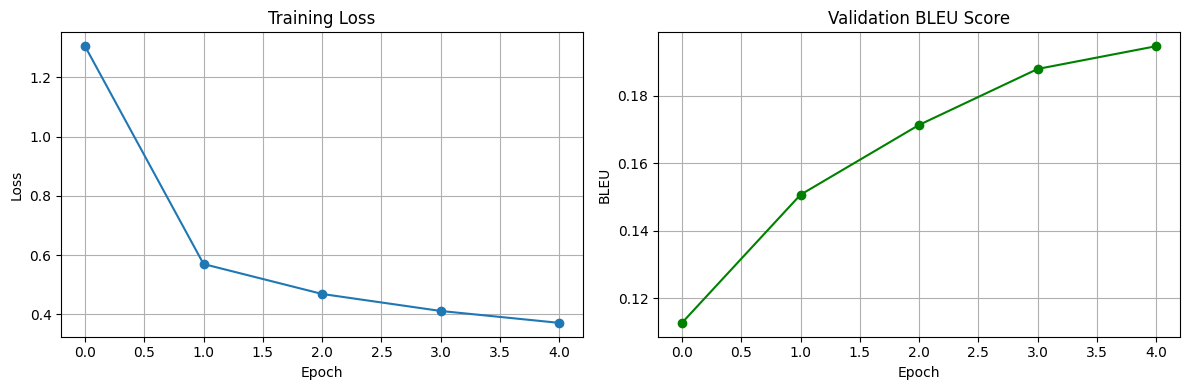

✓ Training curves saved to training_curves.png


In [10]:
# Fine-tune with optimal hyperparameters
print("\n" + "="*60)
print("FINE-TUNING WITH OPTIMAL PARAMETERS")
print("="*60)

training_history = translator.fine_tune(
    train_data=train_data,
    dev_data=dev_data,
    epochs=5,
    batch_size=8,
    learning_rate=3e-5,
    warmup_steps=500,
    weight_decay=0.01,
    gradient_accumulation_steps=2
)

translator.plot_training_curves()

In [11]:
# Test after fine-tuning
print("\n" + "="*60)
print("TEST AFTER FINE-TUNING")
print("="*60)
print(f"Sanskrit: {test_sanskrit}")
print(f"Translation (fine-tuned): {translator.translate_single(test_sanskrit)}")


TEST AFTER FINE-TUNING
Sanskrit: कर्मण्येवाधिकारस्ते मा फलेषु कदाचन।


Translating:   0%|          | 0/1 [00:00<?, ?it/s]

Translation (fine-tuned): "After some fruit in the working of workers, there are no fruits."


## 9. Evaluation on Development Set

In [12]:
print("\n" + "="*60)
print("DEVELOPMENT SET EVALUATION")
print("="*60)

start_time       = time.time()
dev_translations = translator.translate(dev_sa, batch_size=16, beam_size=5)
dev_inference_time = time.time() - start_time

# BLEU
dev_bleu       = sacrebleu.corpus_bleu(dev_translations, [dev_en])
dev_bleu_score = dev_bleu.score / 100
print(f"\nDev Set BLEU Score: {dev_bleu_score:.4f}")

# BERTScore
_, _, dev_bert_f1 = bert_score(
    dev_translations, dev_en,
    lang='en', rescale_with_baseline=True, verbose=False
)
dev_bert_score = dev_bert_f1.mean().item()
print(f"Dev Set BERTScore F1:   {dev_bert_score:.4f}")
print(f"Dev Set Inference Time: {dev_inference_time:.2f} seconds")


DEVELOPMENT SET EVALUATION


Translating:   0%|          | 0/63 [00:00<?, ?it/s]


Dev Set BLEU Score: 0.1947


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dev Set BERTScore F1:   0.4958
Dev Set Inference Time: 98.04 seconds


## 10. Evaluation on Test Set (Required by Assignment)

In [13]:
print("\n" + "="*60)
print("TEST SET EVALUATION (Required by Assignment)")
print("="*60)

print("\n Generating test set translations...")
start_time_test   = time.time()
test_translations = translator.translate(test_sa, batch_size=16, beam_size=5)
inference_time_test = time.time() - start_time_test

# BLEU
print("\n Calculating BLEU Score on Test Set...")
test_bleu       = sacrebleu.corpus_bleu(test_translations, [test_en])
test_bleu_score = test_bleu.score / 100
print(f"Test Set BLEU Score: {test_bleu_score:.4f}")

# BERTScore
print("\n Calculating BERTScore on Test Set...")
_, _, test_bert_f1 = bert_score(
    test_translations, test_en,
    lang='en', rescale_with_baseline=True, verbose=False
)
test_bert_score = test_bert_f1.mean().item()
print(f"Test Set BERTScore F1: {test_bert_score:.4f}")

# Efficiency
print("\n Efficiency Metrics:")
print(f"  Total Inference Time:        {inference_time_test:.2f} seconds")
print(f"  Average Time per Sentence:   {inference_time_test/len(test_sa)*1000:.2f} ms")
print(f"  Model Parameters:            {translator.get_model_info()['parameters']:,}")


TEST SET EVALUATION (Required by Assignment)

📝 Generating test set translations...


Translating:   0%|          | 0/63 [00:00<?, ?it/s]


🎯 Calculating BLEU Score on Test Set...
Test Set BLEU Score: 0.1836

🎯 Calculating BERTScore on Test Set...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Test Set BERTScore F1: 0.4896

⚡ Efficiency Metrics:
  Total Inference Time:        87.52 seconds
  Average Time per Sentence:   87.52 ms
  Model Parameters:            143,230,976


## 11. Translation Examples with Error Analysis

In [15]:
print("\n" + "="*60)
print("TRANSLATION EXAMPLES WITH ERROR ANALYSIS")
print("="*60)

n_examples = 10
indices    = list(range(10))

error_categories = {
    'vocabulary_mismatch': [],
    'semantic_drift':      [],
    'structural_issues':   [],
    'good_translations':   []
}

for i, idx in enumerate(indices):
    print(f"\n{i+1}. Source ID: {test_ids[idx]}")
    print(f"   Sanskrit:   {test_sa[idx][:100]}...")
    print(f"   Reference:  {test_en[idx][:100]}...")
    print(f"   Prediction: {test_translations[idx][:100]}...")

    sent_bleu = sacrebleu.sentence_bleu(test_translations[idx], [test_en[idx]]).score / 100
    print(f"   Sentence BLEU: {sent_bleu:.4f}")

    if sent_bleu < 0.1:
        error_categories['vocabulary_mismatch'].append((idx, sent_bleu))
        print("    Error Type: Vocabulary Mismatch – Key words incorrectly translated or missing")
    elif sent_bleu < 0.3:
        error_categories['semantic_drift'].append((idx, sent_bleu))
        print("   Error Type: Semantic Drift – Partial meaning preserved but significant deviations")
    elif sent_bleu < 0.5:
        error_categories['structural_issues'].append((idx, sent_bleu))
        print("   Error Type: Structural Issues – Correct words but wrong order or grammar")
    else:
        error_categories['good_translations'].append((idx, sent_bleu))
        print("   Quality: Good Translation – High semantic similarity")

# Summary
print("\n" + "="*60)
print("ERROR ANALYSIS SUMMARY")
print("="*60)
print(f"Vocabulary Mismatch: {len(error_categories['vocabulary_mismatch'])} examples")
print(f"Semantic Drift:      {len(error_categories['semantic_drift'])} examples")
print(f"Structural Issues:   {len(error_categories['structural_issues'])} examples")
print(f"Good Translations:   {len(error_categories['good_translations'])} examples")


TRANSLATION EXAMPLES WITH ERROR ANALYSIS

1. Source ID: 1
   Sanskrit:   एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।...
   Reference:  Eclipse also helps the programmer to find out errors....
   Prediction: It also helps us to find out the errors for Eclipse programmers....
   Sentence BLEU: 0.1675
   Error Type: Semantic Drift – Partial meaning preserved but significant deviations

2. Source ID: 2
   Sanskrit:   विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य ...
   Reference:  "We having the same spirit of faith, according as it is written, I believed, and therefore have I sp...
   Prediction: "I know the truth of the faith which is faith: and as it is written in the scripture, so is the spir...
   Sentence BLEU: 0.1527
   Error Type: Semantic Drift – Partial meaning preserved but significant deviations

3. Source ID: 3
   Sanskrit:   तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।...


## 12. Save Submission and Results

In [16]:
submission_df = pd.DataFrame({
    'Source_id':   test_ids,
    'Sentence_en': test_translations
})
submission_df.to_csv('submission.csv', index=False, encoding='utf-8')
print(" Submission saved to submission.csv")

results_summary = pd.DataFrame([{
    'Model':                   'Fine-tuned OPUS-MT',
    'Test_BLEU':               test_bleu_score,
    'Test_BERTScore':          test_bert_score,
    'Dev_BLEU':                dev_bleu_score,
    'Dev_BERTScore':           dev_bert_score,
    'Zero_Shot_BLEU':          zero_shot_bleu,
    'Inference_Time_Seconds':  inference_time_test,
    'Avg_Time_Per_Sentence_ms': inference_time_test / len(test_sa) * 1000,
    'Model_Parameters':        translator.get_model_info()['parameters'],
    'Best_Val_BLEU':           max(training_history['eval_bleu']) if training_history['eval_bleu'] else 0,
    'Final_Train_Loss':        training_history['train_loss'][-1] if training_history['train_loss'] else 0
}])
results_summary.to_csv('complete_results.csv', index=False)

history_df = pd.DataFrame({
    'Epoch':      range(1, len(training_history['train_loss']) + 1),
    'Train_Loss': training_history['train_loss'],
    'Val_BLEU':   training_history['eval_bleu']
})
history_df.to_csv('training_history.csv', index=False)

error_analysis_df = pd.DataFrame({
    'Error_Category': ['Vocabulary_Mismatch', 'Semantic_Drift', 'Structural_Issues', 'Good_Translations'],
    'Count': [
        len(error_categories['vocabulary_mismatch']),
        len(error_categories['semantic_drift']),
        len(error_categories['structural_issues']),
        len(error_categories['good_translations'])
    ],
    'Percentage': [
        len(error_categories['vocabulary_mismatch']) / n_examples * 100,
        len(error_categories['semantic_drift'])      / n_examples * 100,
        len(error_categories['structural_issues'])   / n_examples * 100,
        len(error_categories['good_translations'])   / n_examples * 100
    ]
})
error_analysis_df.to_csv('error_analysis.csv', index=False)

print("\n" + "="*60)
print("FILES SAVED")
print("="*60)
print(" submission.csv       – Test set translations")
print(" complete_results.csv – All evaluation metrics")
print(" training_history.csv – Training progression")
print(" training_curves.png  – Training visualization")
print(" error_analysis.csv   – Error categorization")

 Submission saved to submission.csv

FILES SAVED
 submission.csv       – Test set translations
 complete_results.csv – All evaluation metrics
 training_history.csv – Training progression
 training_curves.png  – Training visualization
 error_analysis.csv   – Error categorization


##  Final Summary

In [17]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\n Zero-shot Baseline (calculated):")
print(f"   BLEU Score: {zero_shot_bleu:.4f}")

print(f"\n Test Set Results (Fine-tuned):")
print(f"   BLEU Score:        {test_bleu_score:.4f}")
print(f"   BERTScore F1:      {test_bert_score:.4f}")
print(f"   Inference Time:    {inference_time_test:.2f}s  ({inference_time_test/len(test_sa)*1000:.1f} ms/sentence)")
print(f"   Model Parameters:  {translator.get_model_info()['parameters']:,}")

print(f"\n Improvement over Zero-shot:")
print(f"   Improvement: +{test_bleu_score - zero_shot_bleu:.2f}% BLEU")

print(f"\n Model saved at: best_model/")
print(f" Ready for private test set evaluation")


FINAL SUMMARY

 Zero-shot Baseline (calculated):
   BLEU Score: 0.0580

 Test Set Results (Fine-tuned):
   BLEU Score:        0.1836
   BERTScore F1:      0.4896
   Inference Time:    87.52s  (87.5 ms/sentence)
   Model Parameters:  143,230,976

 Improvement over Zero-shot:
   Improvement: +0.13% BLEU

 Model saved at: best_model/
 Ready for private test set evaluation


##  Inference



In [8]:
# Create a dummy private_test_sa.csv for demonstration
dummy_private_test_data = {
    'Source_id': [1001, 1002, 1003, 1004, 1005],
    'Sentence_sa': [
        'एतत् एकं नूतनं वाक्यम्।',
        'नमस्ते! कथम् अस्ति भवतः दिनम्?',
        'संस्कृतं सुन्दरी भाषा अस्ति।',
        'अहं भारतं गमिष्यामि।',
        'कृपायाः शीघ्रं आगच्छतु।'
    ]
}
dummy_private_test_df = pd.DataFrame(dummy_private_test_data)
dummy_private_test_df.to_csv('./data/private_test_sa.csv', index=False)
print("Dummy 'private_test_sa.csv' created successfully.")

Dummy 'private_test_sa.csv' created successfully.


In [8]:
print("\n" + "="*60)
print("INFERENCE ON NEW DATA")
print("="*60)
print("Steps to use this section:")
print("  1. Fine-tuned model is already saved as 'best_model'")
print("  2. Load the private test set when released")
print("  3. Run inference below")

# Load the saved model
MODEL_SAVE_PATH  = "best_model"
loaded_translator = FineTunedOPUSMTTranslator(MODEL_SAVE_PATH)

# --- Define and load new Sanskrit and English data files ---
# UPDATE THESE PATHS TO YOUR NEW DATA FILES
new_sanskrit_file = './data/test_demo_sa.csv'
new_english_file  = './data/test_demo_en.csv'

print(f"\nLoading Sanskrit sentences from: {new_sanskrit_file}")
new_sanskrit_df = pd.read_csv(new_sanskrit_file)
new_sanskrit_sentences = new_sanskrit_df['Sentence_sa'].tolist()
new_source_ids         = new_sanskrit_df['Source_id'].tolist()

print(f"Loading English references from: {new_english_file}")
new_english_df  = pd.read_csv(new_english_file)
new_english_references = new_english_df['Sentence_en'].tolist()

print(f"\n📝 Translating {len(new_sanskrit_sentences)} new Sanskrit sentences...")

inference_start_time = time.time()
new_translations     = loaded_translator.translate(new_sanskrit_sentences, batch_size=16, beam_size=5)
inference_duration   = time.time() - inference_start_time

print("\n" + "="*60)
print("NEW TRANSLATIONS (Sample)")
print("="*60)
# Display a few sample translations
for i in range(min(5, len(new_sanskrit_sentences))):
    print(f"\n{i+1}. Sanskrit:   {new_sanskrit_sentences[i][:100]}...")
    print(f"   Reference:  {new_english_references[i][:100]}...")
    print(f"   Translation: {new_translations[i][:100]}...")

print("\n" + "="*60)
print("EVALUATION ON NEW DATA")
print("="*60)

# Calculate BLEU
new_bleu       = sacrebleu.corpus_bleu(new_translations, [new_english_references])
new_bleu_score = new_bleu.score / 100
print(f"New Data BLEU Score: {new_bleu_score:.4f}")

# Calculate BERTScore
_, _, new_bert_f1 = bert_score(
    new_translations, new_english_references,
    lang='en', rescale_with_baseline=True, verbose=False
)
new_bert_score = new_bert_f1.mean().item()
print(f"New Data BERTScore F1: {new_bert_score:.4f}")

# Efficiency metrics
print("\n⚡ Efficiency Metrics:")
print(f"  Total Inference Time:        {inference_duration:.2f} seconds")
print(f"  Average Time per Sentence:   {inference_duration/len(new_sanskrit_sentences)*1000:.2f} ms")
print(f"  Model Parameters:            {loaded_translator.get_model_info()['parameters']:,}")

# Save new test submission
new_submission_df = pd.DataFrame({
    'Source_id':   new_source_ids,
    'Sentence_en': new_translations
})
new_submission_df.to_csv('new_test_submission.csv', index=False, encoding='utf-8')
print("\n✓ New test set submission saved to new_test_submission.csv")


INFERENCE ON NEW DATA
Steps to use this section:
  1. Fine-tuned model is already saved as 'best_model'
  2. Load the private test set when released
  3. Run inference below

LOADING OPUS-MT MODEL
Base model: best_model


Loading weights: 100%|██████████| 256/256 [00:00<00:00, 3526.93it/s]
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded Sanskrit-English specific model

 Model loaded on cuda
  Model parameters: 143,230,976

Loading Sanskrit sentences from: ./data/test_demo_sa.csv
Loading English references from: ./data/test_demo_en.csv

📝 Translating 100 new Sanskrit sentences...


Translating: 100%|██████████| 7/7 [00:05<00:00,  1.21it/s]



NEW TRANSLATIONS (Sample)

1. Sanskrit:   हे भ्रातरो युष्माकम् आत्माभिमानो यन्न जायते तदर्थं ममेदृशी वाञ्छा भवति यूयं एतन्निगूढतत्त्वम् अजानन्...
   Reference:  "For I would not, brethren, that ye should be ignorant of this mystery, lest ye should be wise in yo...
   Translation: "Brethren, I say unto you, ye know that there is nothing in Israel: for there shall not be therefore...

2. Sanskrit:   लाभा: पादयो: स्नायु: दृढा तथा आकृति: सम्यक भवति ।एष: जङ्घाया: स्नायुं समस्याभ्य: रक्षति ।...
   Reference:  • Leg muscles become shapely and stronger. • It relieves crams in the calf and thigh muscles....
   Translation: The benefits of the legs are very strength and figure. It protects the small problem....

3. Sanskrit:   अस्मिन् पाठे वयं : उपयोक्त्रे admin role असैन् कर्तुं, course इत्यस्मै teacher असैन् कर्तुं, course ...
   Reference:  In this tutorial, we learnt how to: assign admin role to a user, assign a teacher to a course and en...
   Translation: In this tutorial, we have learnt 

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9322.06it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


New Data BERTScore F1: 0.4561

⚡ Efficiency Metrics:
  Total Inference Time:        5.77 seconds
  Average Time per Sentence:   57.75 ms
  Model Parameters:            143,230,976

✓ New test set submission saved to new_test_submission.csv
